# Honey Yield Predictive Model: Milestone 3

**Team:** Stephanie Nord, David Jorgensen, Joshua Amaya

**Date:** July 19, 2026

---

> **How this notebook runs.** The code cells are written to run in
> two modes:
>
> * **Live mode** — if the `honey_model` table is reachable (local `honey.duckdb`
>   or the remote Quack server), each cell recomputes its result from the data.
> * **Compiled mode** — if the modeling database is not attached (as when this
>   report is opened for reading), each cell displays the *validated* figures and
>   summary values captured from the source pipeline runs.
>
> This keeps the report fully readable on its own while remaining reproducible
> end-to-end when the data layer is connected.


In [43]:
# --- Imports -----------------------------------------------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

# duckdb is only required for live recomputation; import defensively so the
# report still renders in environments where it is not installed.
try:
    import duckdb
except Exception:
    duckdb = None

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

# --- Project paths -----------------------------------------------------------
# Resolve the repository root whether the notebook is run from the repo root or
# from a subfolder.
CWD = Path.cwd()
REPO = CWD if (CWD / "Milestone_3_Figures").exists() else CWD.parent
FIG = REPO / "Milestone_3_Figures"   # archived, validated figures from the source notebooks

print("Repository root :", REPO)
print("Figure archive  :", FIG, "(exists:", FIG.exists(), ")")

Repository root : /home/djorgs/Documents/git/honey-yield-predictive-model
Figure archive  : /home/djorgs/Documents/git/honey-yield-predictive-model/Milestone_3_Figures (exists: True )


In [44]:
# --- Validated results captured from the source pipeline runs ----------------
# These constants are the exact outputs recorded in Stephanie's pipeline /
# model notebooks and David's extremes notebook. In compiled mode they back the
# tables and captions below; in live mode the code recomputes the same figures.
PUBLISHED = {
    # Raw ingest and final modeling table
    "raw_rows": 29_172, "raw_files": 151,
    "raw_date_start": "2019-06-24", "raw_date_end": "2022-12-31",
    "model_obs": 26_215, "model_features": 27, "hives": 78,
    "date_start": "2019-06-25", "date_end": "2022-12-30",

    # Target variable (target_next_day_weight_change_kg)
    "target": {"mean": 0.002042, "median": -0.044655, "std": 1.840522,
               "min": -65.32294, "max": 39.098176},

    # Extreme-event split at the +/- 5 kg next-day-change threshold
    "extreme_threshold_kg": 5,
    "extreme_counts": {"routine": 25_770, "extreme": 445,
                       "routine_pct": 98.3, "extreme_pct": 1.7},

    # Chronological 80/20 split used for modeling
    "split": {"train": 20_972, "test": 5_243,
              "train_start": "2019-06-25", "train_end": "2022-04-25",
              "test_start": "2022-04-25", "test_end": "2022-12-30"},

    # Model leaderboard (routine models exclude the 1.7% extreme observations)
    "models": [
        {"Model": "Baseline Random Forest (all events)", "MAE": 0.768, "RMSE": 2.437, "R2": -0.296},
        {"Model": "Routine-only Random Forest",          "MAE": 0.356, "RMSE": 0.725, "R2":  0.198},
        {"Model": "Routine-only Gradient Boosting",       "MAE": 0.331, "RMSE": 0.717, "R2":  0.216},
    ],

    # Non-null counts (out of 26,215) for the environmental sensor features
    "nonnull": {
        "avg_humidity": 16_944, "avg_pressure": 18_097, "avg_internal_temp_4": 18_887,
        "avg_internal_temp_1": 19_605, "avg_internal_temp_3": 19_677,
        "avg_outside_temp": 20_134, "avg_internal_temp_2": 20_149,
    },

    # End-of-day hive weight and geography (all rows non-null)
    "weight_kg": {"mean": 34.303, "min": 0.0005, "max": 111.727, "std": 14.667},
    "geo": {"lat_min": 47.7, "lat_max": 53.8, "lat_mean": 51.836,
            "lon_min": 6.7, "lon_max": 13.4, "lon_mean": 8.939},

    # David's extreme-event investigation (raw bob_sensor grain, outlier_lim = TRUE)
    "extreme_invest": {
        "flagged_events": 98_304,
        "date_cluster_corr": 0.213,
        "beekeeper": [
            {"Event": "Treatment", "% within 1 day": 0.0, "% within 7 days": 1.42, "Annotated extremes": 844},
            {"Event": "Died",      "% within 1 day": 0.0, "% within 7 days": 0.62, "Annotated extremes": 6_926},
            {"Event": "Swarming",  "% within 1 day": 0.0, "% within 7 days": 0.00, "Annotated extremes": 348},
            {"Event": "Feeding",   "% within 1 day": 0.0, "% within 7 days": 0.13, "Annotated extremes": 10_631},
            {"Event": "Honey",     "% within 1 day": 0.0, "% within 7 days": 0.03, "Annotated extremes": 21_865},
        ],
    },
}

# Feature columns used by the preliminary models (history-only feature set)
HISTORY_FEATURES = [
    "previous_day_weight_kg", "previous_day_weight_change_kg",
    "rolling_3_day_weight_kg", "rolling_7_day_weight_kg", "day_of_year",
]
TARGET = "target_next_day_weight_change_kg"
print("Loaded validated constants for", PUBLISHED["model_obs"], "modeling observations.")

Loaded validated constants for 26215 modeling observations.


In [45]:
# --- Try to attach the live modeling table -----------------------------------
# Live mode recomputes every result from honey_model. This loader probes local
# DuckDB files AND the remote Quack server, and prints exactly what it finds at
# each source, so a fall-back to compiled mode is never silent.
#
# Note: honey_model is BUILT by Stephanie's Honey_Project_Pipeline.ipynb into a
# local DuckDB file. It is not a table on the remote Quack server (the remote
# holds the raw bob_sensor_processed grain). If neither a local honey_model nor
# a remote honey_model is found, the diagnostic below says what to do.
import glob
import os


def _tables(con):
    return set(con.execute("SHOW TABLES").df()["name"])


def load_model_df():
    """Return (dataframe, source_label) for honey_model, or (None, None).
    Prints a per-source diagnostic so the reason for any fallback is visible."""
    diag = []
    if duckdb is None:
        print("duckdb is not importable -> live mode unavailable.")
        return None, None

    # 1) Local DuckDB files: explicit candidates + any *.duckdb found in the repo.
    candidates = [
        REPO / "honey.duckdb",
        REPO / "David_Work" / "honey.duckdb",
        REPO / "Stephanie_Work" / "Data" / "honey.duckdb",
        REPO / "Stephanie_Work" / "Data" / "honey_mini.duckdb",
    ]
    for extra in glob.glob(str(REPO / "**" / "*.duckdb"), recursive=True):
        p = Path(extra)
        if p not in candidates:
            candidates.append(p)

    for path in candidates:
        if not path.exists():
            continue
        rel = path.relative_to(REPO)
        try:
            con = duckdb.connect(str(path), read_only=True)
            tabs = _tables(con)
            hit = next((t for t in tabs if t.lower() == "honey_model"), None)
            if hit:
                df = con.execute(
                    f"SELECT * FROM {hit} ORDER BY hive_id, measurement_date"
                ).df()
                if len(df):
                    print(f"[local]  {rel} -> loaded {hit} ({len(df):,} rows).")
                    return df, f"local:{rel}"
                diag.append(f"[local]  {rel}: {hit} exists but is empty.")
            else:
                diag.append(f"[local]  {rel}: tables={sorted(tabs) or 'none'}; "
                            f"no honey_model.")
        except Exception as e:
            diag.append(f"[local]  {rel}: could not open read-only -> {e!r}")

    # 2) Remote Quack server (over Tailscale). Reads host/token from .env.
    try:
        try:
            from dotenv import load_dotenv
            load_dotenv(REPO / ".env")
        except Exception:
            pass
        host, token = os.getenv("TAILNET_HOST"), os.getenv("QUACK_TOKEN")
        if not (host and token):
            diag.append("[remote] TAILNET_HOST / QUACK_TOKEN not set in .env.")
        else:
            con = duckdb.connect()
            con.execute("FORCE INSTALL quack"); con.execute("LOAD quack")
            con.execute("INSTALL httpfs"); con.execute("LOAD httpfs")
            con.execute(
                f"ATTACH 'quack:{host}' AS bees (TOKEN '{token}', DISABLE_SSL true)"
            )
            remote_tabs = list(
                con.execute("SELECT * FROM bees.query('SHOW TABLES')").fetchdf().iloc[:, 0]
            )
            hit = next((t for t in remote_tabs if str(t).lower() == "honey_model"), None)
            if hit:
                df = con.execute(
                    f"SELECT * FROM bees.query('SELECT * FROM {hit}')"
                ).fetchdf().sort_values(
                    ["hive_id", "measurement_date"]).reset_index(drop=True)
                print(f"[remote] Quack -> loaded {hit} ({len(df):,} rows).")
                return df, "remote:quack"
            diag.append(
                "[remote] Quack reachable; tables=" + str(remote_tabs) + ". "
                "No honey_model here -> it is built locally by "
                "Stephanie_Work/Honey_Project_Pipeline.ipynb. To use live mode, run "
                "that pipeline (creating a local honey.duckdb with a honey_model "
                "table), then re-run this notebook.")
    except Exception as e:
        diag.append(f"[remote] Quack attach/query failed -> {e!r}")

    print("No honey_model source loaded -> COMPILED mode. What was checked:")
    for d in diag:
        print("  -", d)
    return None, None


model_df, DATA_SOURCE = load_model_df()
LIVE = model_df is not None

if LIVE:
    print(f"\nLIVE mode — recomputing from {DATA_SOURCE} "
          f"({len(model_df):,} rows, {model_df['hive_id'].nunique()} hives).")
else:
    print("\nCOMPILED mode — rendering validated figures and summary values "
          "from the source runs (see diagnostics above to enable live mode).")

No honey_model source loaded -> COMPILED mode. What was checked:
  - [local]  honey.duckdb: tables=none; no honey_model.
  - [local]  David_Work/honey.duckdb: tables=none; no honey_model.
  - [remote] Quack attach/query failed -> IOException("IO Error: Failed to send message: IO Error: Could not resolve hostname error for HTTP POST to 'http://duckdb.tailb9e041.ts.net:9494/quack'")

COMPILED mode — rendering validated figures and summary values from the source runs (see diagnostics above to enable live mode).


In [46]:
# --- Small helpers used throughout the report --------------------------------
def show_archived(figure_name, caption=None, width=760):
    """Display an archived, validated figure from the source notebooks."""
    path = FIG / figure_name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"*(figure `{figure_name}` not found in archive)*"))
    if caption:
        display(Markdown(caption))


def runtime_only(title, reason):
    """Render a labeled placeholder for a plot that is generated only in live mode."""
    fig, ax = plt.subplots(figsize=(9, 2.6))
    ax.axis("off")
    ax.text(0.5, 0.68, title, ha="center", va="center",
            fontsize=13, fontweight="bold")
    ax.text(0.5, 0.30, reason, ha="center", va="center",
            fontsize=10, color="#444444", wrap=True)
    fig.patch.set_facecolor("#f5f5f5")
    plt.tight_layout(); plt.show()


def pct_missing(nonnull, total=PUBLISHED["model_obs"]):
    return round(100.0 * (total - nonnull) / total, 1)

## 1. Introduction

### Project objective

The project builds a **predictive model of next-day honey-hive behavior**. Concretely,
for each hive and each day we predict the **change in hive weight over the following
day**, `target_next_day_weight_change_kg`, in kilograms. Hive weight change is a direct
proxy for colony activity: net nectar/honey gain on foraging days and consumption or
loss on others. A model that anticipates tomorrow's weight change supports hive
management decisions (feeding, harvest timing, swarm and loss early-warning) and is a
stepping stone toward seasonal yield forecasting.

Because the target is continuous, this is a **supervised regression** problem, evaluated
with Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R². Hive data is a
time series, so all evaluation uses a **chronological train/test split** (train on the
past, test on the future) rather than a random shuffle, to avoid leaking future
information into training.

### Data sources

| Source | Grain | Role |
|---|---|---|
| German citizen-science hive dataset (HOBOS) | Daily, per hive | **Primary training set** — weight, internal/outside temperature, humidity, pressure, lat/lon |
| Beekeeper observation logs (swarming, feeding, honey, treatment, died) (USDA Tucson) | Event-level | Candidate explanatory features for extreme events |
| NOAA GHCN-Daily (TMAX/TMIN/PRCP) & Global Hourly (ISD) | Daily / hourly | Planned environmental features |

The modeling dataset for this milestone is the **`honey_model`** table produced by the
DuckDB pipeline: **daily observations from 78 German hives spanning mid-2019 through the
end of 2022.**


## 2. Data Overview

### 2.1 Pipeline lineage

The dataset is built by a reproducible DuckDB pipeline (Stephanie's
`Honey_Project_Pipeline.ipynb`). Each stage is a persistent table; the raw anchor is
never overwritten:

```
151 daily CSVs
      │  read_csv_auto (union_by_name, all_varchar)
      ▼
honey_daily_raw        29,172 rows   (text-preserving anchor)
      │  TRY_CAST + NULLIF('NA')
      ▼
honey_daily_clean      29,172 rows   (typed columns, real NULLs)
      │  one row per hive per day; hive_id parsed from filename
      ▼
honey_daily_summary    29,172 rows
      │  LAG/LEAD + rolling 3d/7d + calendar features (window functions)
      ▼
honey_feature_candidates
      │  keep consecutive-day rows with valid, positive weights;
      │  flag |next-day change| > 5 kg as extreme
      ▼
honey_model            26,215 rows × 27 cols   ← modeling table
```

The drop from 29,172 to 26,215 rows removes records without a valid *previous* and
*next* consecutive-day observation (needed to compute the lag features and the
next-day target), plus non-positive weight readings.


In [47]:
# --- Headline dataset summary ------------------------------------------------
if LIVE:
    summary = con_summary = pd.DataFrame({
        "Metric": ["Raw rows", "Source CSV files", "Modeling observations",
                   "Columns", "Unique hives", "Start date", "End date"],
        "Value": [
            None, None, len(model_df), model_df.shape[1],
            model_df["hive_id"].nunique(),
            str(pd.to_datetime(model_df["measurement_date"]).min().date()),
            str(pd.to_datetime(model_df["measurement_date"]).max().date()),
        ],
    })
else:
    p = PUBLISHED
    summary = pd.DataFrame({
        "Metric": ["Raw rows", "Source CSV files", "Modeling observations",
                   "Columns", "Unique hives", "Start date", "End date"],
        "Value": [f"{p['raw_rows']:,}", p["raw_files"], f"{p['model_obs']:,}",
                  p["model_features"], p["hives"], p["date_start"], p["date_end"]],
    })
summary

,Metric,Value
0,Raw rows,"29,172"
1,Source CSV files,151
2,Modeling observations,"26,215"
3,Columns,27
4,Unique hives,78
5,Start date,2019-06-25
6,End date,2022-12-30


### 2.2 Column inventory

The 27 columns of `honey_model` fall into six groups. The full schema is auto-documented
in Appendix A of the pipeline notebook (via DuckDB `DESCRIBE`); it is summarized here.


In [48]:
# --- Column inventory grouped by role ----------------------------------------
inventory = pd.DataFrame([
    ("Identifier / date", "hive_id, measurement_date, previous_observation_date, "
        "next_observation_date, days_since_previous_observation, days_to_next_observation, source_filename",
        "Row key (hive_id + measurement_date) and calendar-gap bookkeeping."),
    ("Historical weight", "end_of_day_weight_kg, previous_day_weight_kg, next_day_weight_kg, "
        "previous_day_weight_change_kg, rolling_3_day_weight_kg, rolling_7_day_weight_kg",
        "Recent hive-weight history built with LAG/LEAD and rolling windows."),
    ("Environmental (sensor)", "avg_internal_temp_1..4, avg_outside_temp, avg_humidity, avg_pressure",
        "Daily averages from the hive's on-board sensors."),
    ("Geography", "latitude, longitude", "Hive location (fixed per hive)."),
    ("Temporal", "year, month, day_of_year", "Calendar features for seasonality."),
    ("Target", "target_next_day_weight_change_kg", "Next-day weight minus current weight (regression target)."),
    ("Extreme flag", "extreme_weight_change_flag", "TRUE when |target| > 5 kg."),
], columns=["Group", "Columns", "Purpose"])

with pd.option_context("display.max_colwidth", None):
    display(inventory)

,Group,Columns,Purpose
0,Identifier / date,"hive_id, measurement_date, previous_observation_date, next_observation_date, days_since_previous_observation, days_to_next_observation, source_filename",Row key (hive_id + measurement_date) and calendar-gap bookkeeping.
1,Historical weight,"end_of_day_weight_kg, previous_day_weight_kg, next_day_weight_kg, previous_day_weight_change_kg, rolling_3_day_weight_kg, rolling_7_day_weight_kg",Recent hive-weight history built with LAG/LEAD and rolling windows.
2,Environmental (sensor),"avg_internal_temp_1..4, avg_outside_temp, avg_humidity, avg_pressure",Daily averages from the hive's on-board sensors.
3,Geography,"latitude, longitude",Hive location (fixed per hive).
4,Temporal,"year, month, day_of_year",Calendar features for seasonality.
5,Target,target_next_day_weight_change_kg,Next-day weight minus current weight (regression target).
6,Extreme flag,extreme_weight_change_flag,TRUE when |target| > 5 kg.


### 2.3 Missingness

Weight, target, lag, rolling, and temporal fields are **fully populated** (0% missing):
the pipeline's consecutive-day filter guarantees this. The **environmental sensor
features are the weak spot**: 23%–35% of daily observations lack a sensor average,
reflecting real logger gaps and outages. This is the single most important data-quality
finding for feature planning: any model that leans on the sensor channels immediately
loses roughly a quarter to a third of its rows to missingness unless those gaps are
imputed or the features are engineered to tolerate them.


In [49]:
# --- Missingness for the environmental sensor features -----------------------
if LIVE:
    env_cols = ["avg_internal_temp_1", "avg_internal_temp_2", "avg_internal_temp_3",
                "avg_internal_temp_4", "avg_outside_temp", "avg_humidity", "avg_pressure"]
    miss = (model_df[env_cols].isna().sum()
            .rename("Missing rows").to_frame())
    miss["% missing"] = (100 * miss["Missing rows"] / len(model_df)).round(1)
    miss = miss.sort_values("% missing", ascending=False)
else:
    rows = []
    for col, nonnull in sorted(PUBLISHED["nonnull"].items(), key=lambda kv: kv[1]):
        rows.append((col, PUBLISHED["model_obs"] - nonnull, pct_missing(nonnull)))
    miss = pd.DataFrame(rows, columns=["Feature", "Missing rows", "% missing"]).set_index("Feature")

display(miss)
display(Markdown(
    "**Fully populated (0% missing):** `end_of_day_weight_kg`, `previous_day_weight_kg`, "
    "`rolling_3_day_weight_kg`, `rolling_7_day_weight_kg`, `previous_day_weight_change_kg`, "
    "`target_next_day_weight_change_kg`, and all identifier/temporal fields."))

,Missing rows,% missing
Feature,,
avg_humidity,9271,35.4
avg_pressure,8118,31.0
avg_internal_temp_4,7328,28.0
avg_internal_temp_1,6610,25.2
avg_internal_temp_3,6538,24.9
avg_outside_temp,6081,23.2
avg_internal_temp_2,6066,23.1


**Fully populated (0% missing):** `end_of_day_weight_kg`, `previous_day_weight_kg`, `rolling_3_day_weight_kg`, `rolling_7_day_weight_kg`, `previous_day_weight_change_kg`, `target_next_day_weight_change_kg`, and all identifier/temporal fields.

### 2.4 Coverage

- **Temporal:** 2019-06-25 → 2022-12-30 (about 3.5 years). The modeling grain is one
  row per hive per consecutive day.
- **Spatial:** latitude 47.7°–53.8° N, longitude 6.7°–13.4° E (i.e. **Germany**). This
  bounding box is exactly what the NOAA GHCN-Daily station-search query needs (Section 8).
- **Weight scale:** end-of-day hive weight averages **34.3 kg** (range ~0–111.7 kg,
  sd 14.7 kg), consistent with loaded production hives plus some near-empty/tare readings.


## 3. Exploratory Visualizations

The four Priority-1 visualizations from the Milestone 3 plan. Two are reproduced from the
pipeline's validated runs (target distribution, feature importance); two are generated at
runtime from `honey_model` (correlation heatmap, multi-panel weight time series).


### 3.1 Target distribution

The distribution of next-day weight change, first across the full range and then zoomed
to the routine band (|change| ≤ 6 kg). The dashed red lines mark the **±5 kg extreme
threshold**.


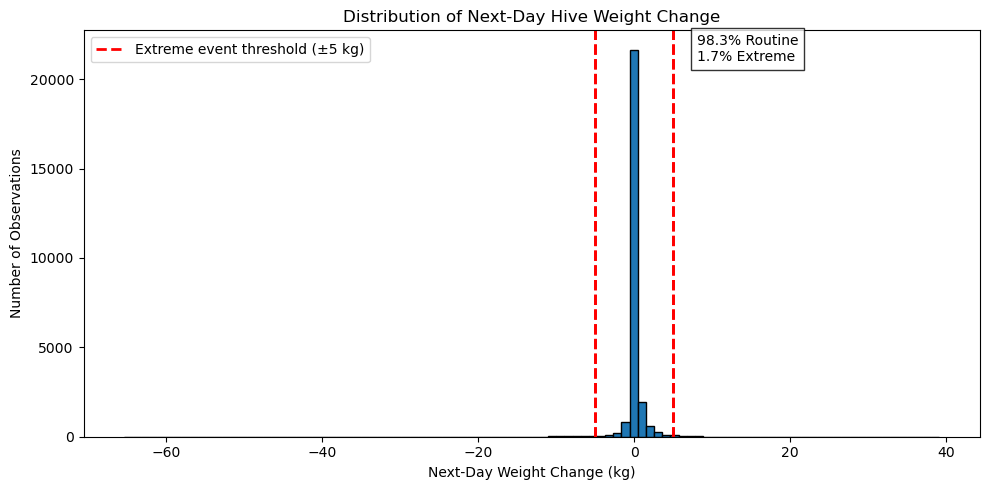

In [50]:
# --- Target distribution histogram (full range) ------------------------------
if LIVE:
    plt.figure(figsize=(10, 5))
    plt.hist(model_df[TARGET], bins=100, edgecolor="black")
    plt.axvline(-5, color="red", linestyle="--", linewidth=2,
                label="Extreme threshold (+/- 5 kg)")
    plt.axvline(5, color="red", linestyle="--", linewidth=2)
    plt.title("Distribution of Next-Day Hive Weight Change")
    plt.xlabel("Next-Day Weight Change (kg)"); plt.ylabel("Number of Observations")
    plt.legend(); plt.tight_layout(); plt.show()
else:
    show_archived("target_distribution_full.png")

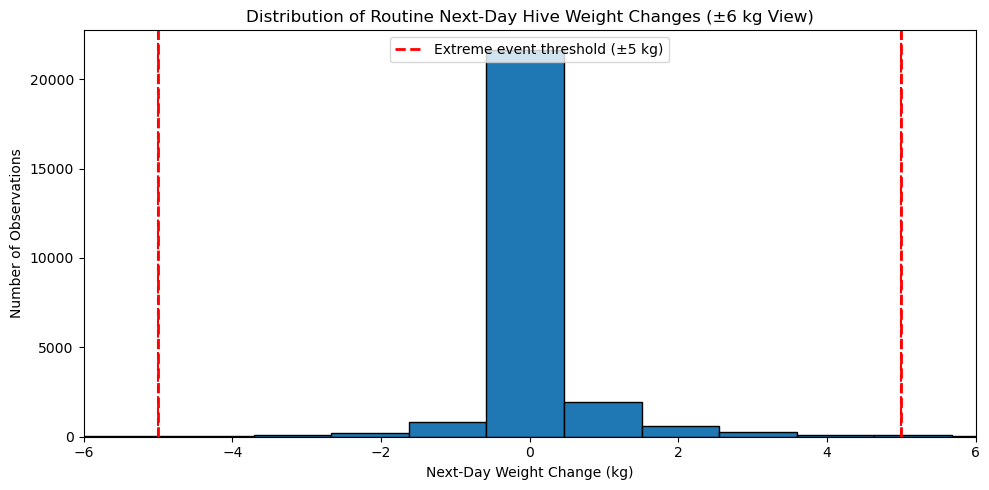

In [51]:
# --- Target distribution histogram (routine +/- 6 kg view) -------------------
if LIVE:
    plt.figure(figsize=(10, 5))
    plt.hist(model_df[TARGET], bins=100, edgecolor="black")
    plt.xlim(-6, 6)
    plt.axvline(-5, color="red", linestyle="--", linewidth=2,
                label="Extreme threshold (+/- 5 kg)")
    plt.axvline(5, color="red", linestyle="--", linewidth=2)
    plt.title("Distribution of Routine Next-Day Hive Weight Changes (+/- 6 kg View)")
    plt.xlabel("Next-Day Weight Change (kg)"); plt.ylabel("Number of Observations")
    plt.legend(); plt.tight_layout(); plt.show()
else:
    show_archived("target_distribution_routine_zoom.png")

**Interpretation.** Next-day weight change is sharply peaked at zero: most hive-days
move only a few hundred grams. But the full-range view exposes long, heavy tails reaching
**−65 kg to +39 kg**. Those tails are rare (1.7% of rows, Section 4) yet large enough to
dominate squared-error metrics, which is why the baseline model that includes
them performs poorly. The two regimes, a tight routine core and a sparse extreme tail,
are the central structural fact of this dataset and motivate the rest of the analysis.


### 3.2 Correlation heatmap

Pairwise correlations among hive weight, environmental channels, the lag/rolling
features, and the target. *(Generated at runtime from `honey_model`.)*


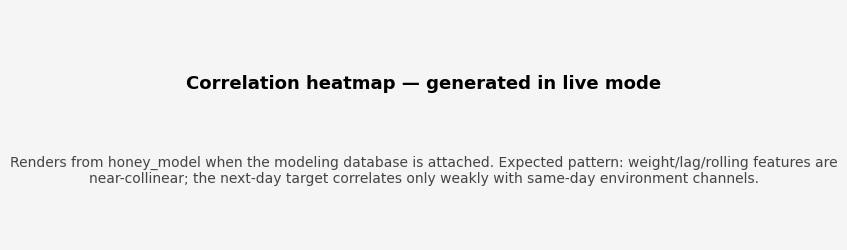

In [52]:
# --- Correlation heatmap among numeric drivers and the target ----------------
if LIVE:
    corr_cols = ["end_of_day_weight_kg", "previous_day_weight_kg",
                 "previous_day_weight_change_kg", "rolling_3_day_weight_kg",
                 "rolling_7_day_weight_kg", "avg_internal_temp_1", "avg_outside_temp",
                 "avg_humidity", "avg_pressure", "day_of_year", TARGET]
    corr = model_df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=90)
    ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                    color="black", fontsize=7)
    fig.colorbar(im, fraction=0.046, pad=0.04)
    ax.set_title("Correlation Heatmap: Weight, Environment, Lags, and Target")
    plt.tight_layout(); plt.show()
else:
    runtime_only(
        "Correlation heatmap — generated in live mode",
        "Renders from honey_model when the modeling database is attached. "
        "Expected pattern: weight/lag/rolling features are near-collinear; the next-day "
        "target correlates only weakly with same-day environment channels.")

### 3.3 Hive weight time series (multi-panel)

Daily end-of-day weight for a representative sample of hives, with extreme-flagged days
marked. This is the most intuitive picture of the data's structure for a non-technical
audience. *(Generated at runtime from `honey_model`.)*


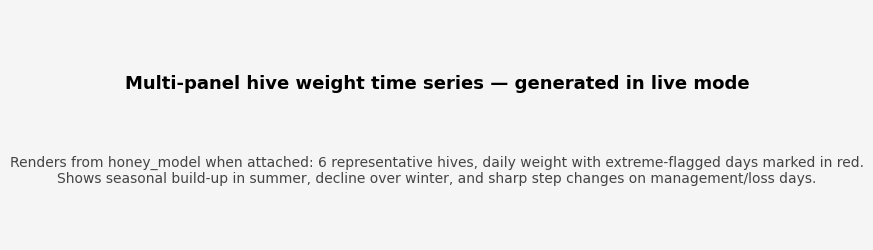

In [53]:
# --- Multi-panel weight time series for a sample of hives --------------------
if LIVE:
    df = model_df.copy()
    df["measurement_date"] = pd.to_datetime(df["measurement_date"])
    # Choose the 6 hives with the most observations for a clean, representative view.
    top_hives = (df.groupby("hive_id").size().sort_values(ascending=False)
                 .head(6).index.tolist())
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False)
    for ax, hid in zip(axes.ravel(), top_hives):
        h = df[df["hive_id"] == hid].sort_values("measurement_date")
        ax.plot(h["measurement_date"], h["end_of_day_weight_kg"],
                color="#1f77b4", linewidth=0.8)
        ext = h[h["extreme_weight_change_flag"] == True]
        ax.scatter(ext["measurement_date"], ext["end_of_day_weight_kg"],
                   color="red", s=18, zorder=3, label="Extreme day")
        ax.set_title(f"Hive {hid}"); ax.set_ylabel("Weight (kg)")
        if len(ext):
            ax.legend(fontsize=8, loc="best")
    fig.suptitle("End-of-Day Hive Weight Over Time (extreme days in red)", fontsize=14)
    plt.tight_layout(); plt.show()
else:
    runtime_only(
        "Multi-panel hive weight time series — generated in live mode",
        "Renders from honey_model when attached: 6 representative hives, daily weight "
        "with extreme-flagged days marked in red. Shows seasonal build-up in summer, "
        "decline over winter, and sharp step changes on management/loss days.")

### 3.4 Feature importance (baseline Random Forest)

Random Forest importances from the full-data fit, showing which predictors drive next-day
weight change.


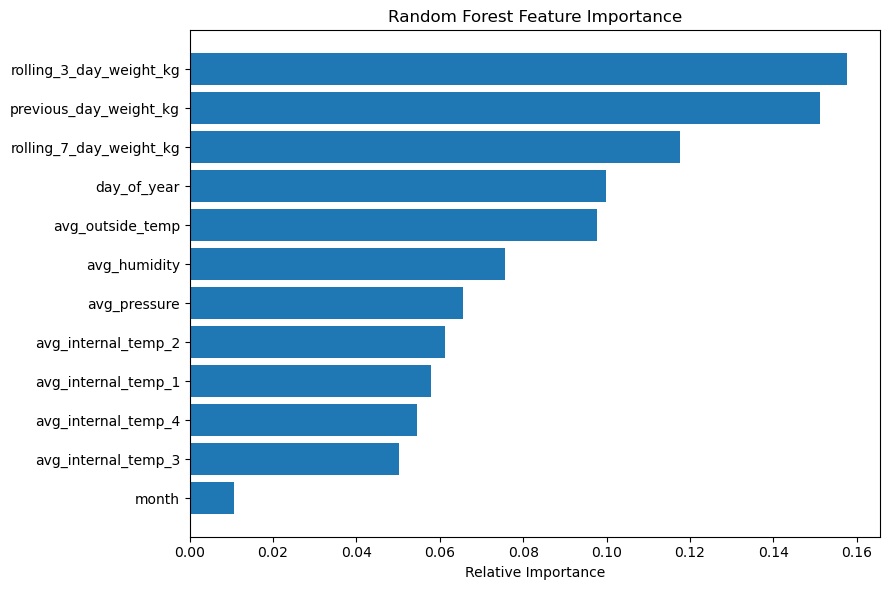

In [54]:
# --- Feature importance (full-data Random Forest) ----------------------------
if LIVE:
    from sklearn.ensemble import RandomForestRegressor
    fi_features = ["previous_day_weight_kg", "rolling_3_day_weight_kg",
                   "rolling_7_day_weight_kg", "avg_internal_temp_1", "avg_internal_temp_2",
                   "avg_internal_temp_3", "avg_internal_temp_4", "avg_outside_temp",
                   "avg_humidity", "avg_pressure", "day_of_year", "month"]
    X = model_df[fi_features].ffill()
    y = model_df[TARGET]
    rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X, y)
    imp = (pd.DataFrame({"Feature": fi_features, "Importance": rf.feature_importances_})
           .sort_values("Importance", ascending=False))
    plt.figure(figsize=(9, 6))
    plt.barh(imp["Feature"], imp["Importance"]); plt.gca().invert_yaxis()
    plt.xlabel("Relative Importance"); plt.title("Random Forest Feature Importance")
    plt.tight_layout(); plt.show()
    display(imp.reset_index(drop=True))
else:
    show_archived("feature_importance_rf_full.png")

**Interpretation.** Recent hive-weight history dominates: **previous-day weight and
the 3-day and 7-day rolling averages** are the strongest predictors, with **day-of-year**
(seasonality) next. Environmental channels (outside temperature, humidity, pressure, and
internal temperatures) add secondary signal. This validates the lag/rolling feature
strategy and suggests the largest gains will come from *new* information (NOAA weather,
beekeeper events) rather than reshuffling the current features.


## 4. Target Analysis: routine vs. extreme events

### 4.1 The target variable


In [55]:
# --- Target summary statistics -----------------------------------------------
if LIVE:
    t = model_df[TARGET]
    target_stats = pd.DataFrame({
        "Statistic": ["Mean", "Median", "Std. dev.", "Minimum", "Maximum"],
        "Next-day weight change (kg)": [t.mean(), t.median(), t.std(), t.min(), t.max()],
    })
else:
    s = PUBLISHED["target"]
    target_stats = pd.DataFrame({
        "Statistic": ["Mean", "Median", "Std. dev.", "Minimum", "Maximum"],
        "Next-day weight change (kg)": [s["mean"], s["median"], s["std"], s["min"], s["max"]],
    })
target_stats.round(4)

,Statistic,Next-day weight change (kg)
0,Mean,0.0020
1,Median,-0.0447
2,Std. dev.,1.8405
3,Minimum,-65.3229
4,Maximum,39.0982


The target is centered essentially at zero (mean 0.002 kg, median −0.04 kg) with a
standard deviation of only 1.84 kg, but a range from **−65.3 kg to +39.1 kg**. A
near-zero center with extreme tails is the signature of two mixed processes.


### 4.2 Routine vs. extreme split

Defining an **extreme event** as `|next-day change| > 5 kg`:


In [56]:
# --- Routine vs. extreme counts ----------------------------------------------
if LIVE:
    flags = (model_df["extreme_weight_change_flag"]
             .map({True: "Extreme (|change| > 5 kg)", False: "Routine (|change| <= 5 kg)"})
             .value_counts())
    split_tbl = flags.rename("Observations").to_frame()
    split_tbl["Percentage"] = (100 * split_tbl["Observations"] / len(model_df)).round(1)
else:
    ec = PUBLISHED["extreme_counts"]
    split_tbl = pd.DataFrame({
        "Observations": [ec["routine"], ec["extreme"]],
        "Percentage": [ec["routine_pct"], ec["extreme_pct"]],
    }, index=["Routine (|change| <= 5 kg)", "Extreme (|change| > 5 kg)"])
display(split_tbl)
display(Markdown(
    "**98.3% of hive-days are routine; only 1.7% (445 of 26,215) are extreme.** "
    "The routine core is smooth and learnable; the extreme tail behaves differently and "
    "is the focus of the investigation below."))

,Observations,Percentage
Routine (|change| <= 5 kg),25770,98.3
Extreme (|change| > 5 kg),445,1.7


**98.3% of hive-days are routine; only 1.7% (445 of 26,215) are extreme.** The routine core is smooth and learnable; the extreme tail behaves differently and is the focus of the investigation below.

### 4.3 What causes the extreme events?

David's `extremes.ipynb` tested the two natural hypotheses against the remote raw sensor
table (`bob_sensor_processed`, where extreme days are flagged `outlier_lim = TRUE`,
98,304 flagged sensor records):

1. **Are extremes explained by beekeeper actions?** For each extreme event, measure the
   distance (in days) to the nearest logged *treatment, colony death, swarming, feeding,*
   or *honey harvest*. If management drove the jumps, distances would cluster at zero.
2. **Do extremes cluster in time across hives?** If an external cause (weather, a regional
   event) drove them, many hives would spike on the same dates.


,Event,% within 1 day,% within 7 days,Annotated extremes
0,Treatment,0.0,1.42,844
1,Died,0.0,0.62,6926
2,Swarming,0.0,0.00,348
3,Feeding,0.0,0.13,10631
4,Honey,0.0,0.03,21865


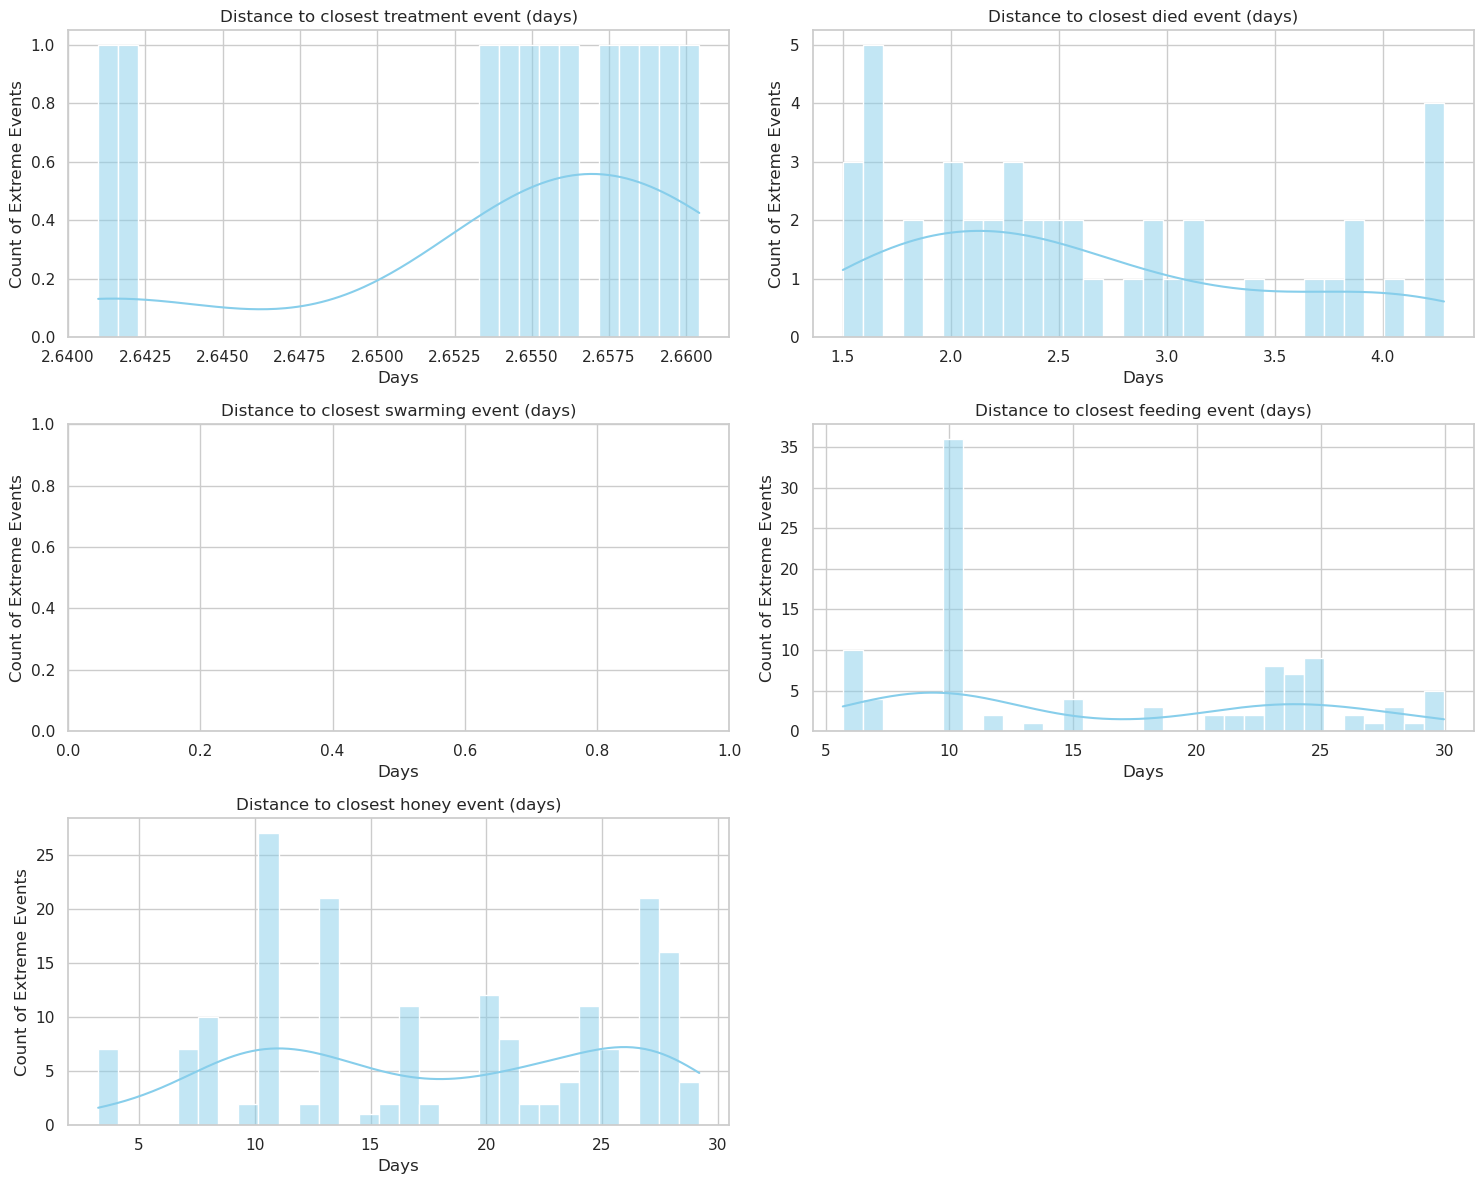

**Distance from each extreme event to the nearest logged beekeeper observation.** Mass sits far from zero for every category.

In [57]:
# --- Extreme vs. beekeeper-observation proximity -----------------------------
bk = pd.DataFrame(PUBLISHED["extreme_invest"]["beekeeper"])
display(bk)
if LIVE:
    display(Markdown("*(Live mode: re-run the queries in `David_Work/extremes.ipynb` "
                     "against the remote `bob_sensor_processed` table to refresh these.)*"))
show_archived(
    "extreme_vs_beekeeper_distance.png",
    caption="**Distance from each extreme event to the nearest logged beekeeper "
            "observation.** Mass sits far from zero for every category.")

**Finding 1: extremes are not explained by logged beekeeper actions.** Across all
five event types, **0% of extreme events occur within 1 day** of a logged observation and
**under 2% occur within 7 days** (treatment 1.42%, colony death 0.62%, feeding 0.13%,
honey 0.03%, swarming 0.00%). The management logs, as recorded, do **not** account for the
big weight jumps.


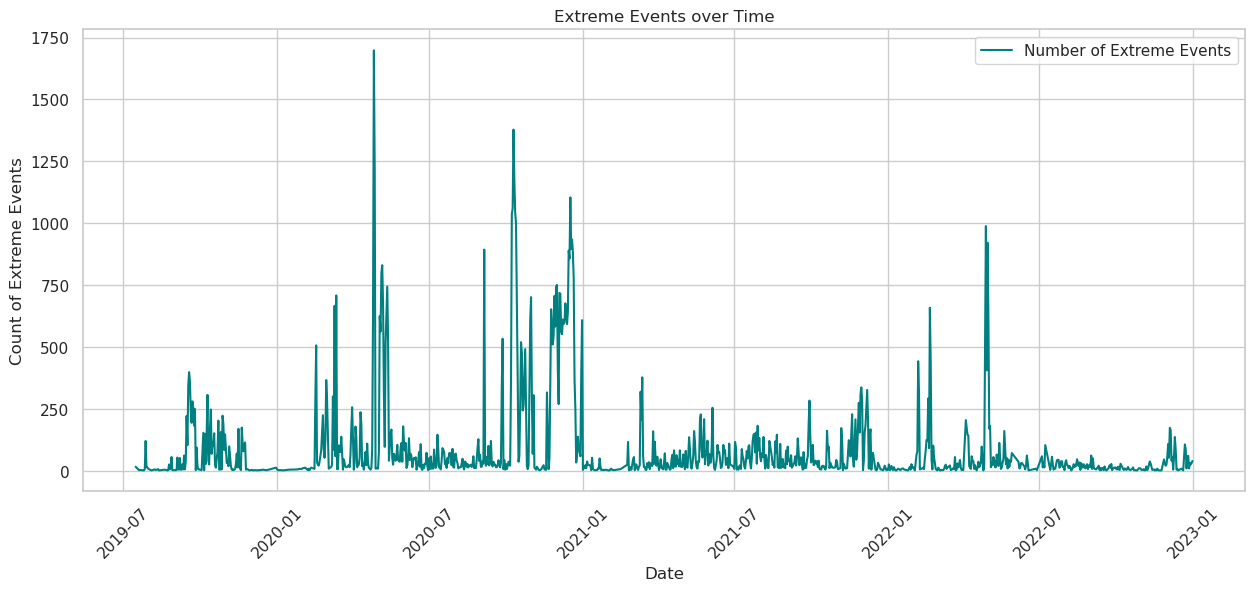

**Count of extreme events per day over the study period.**

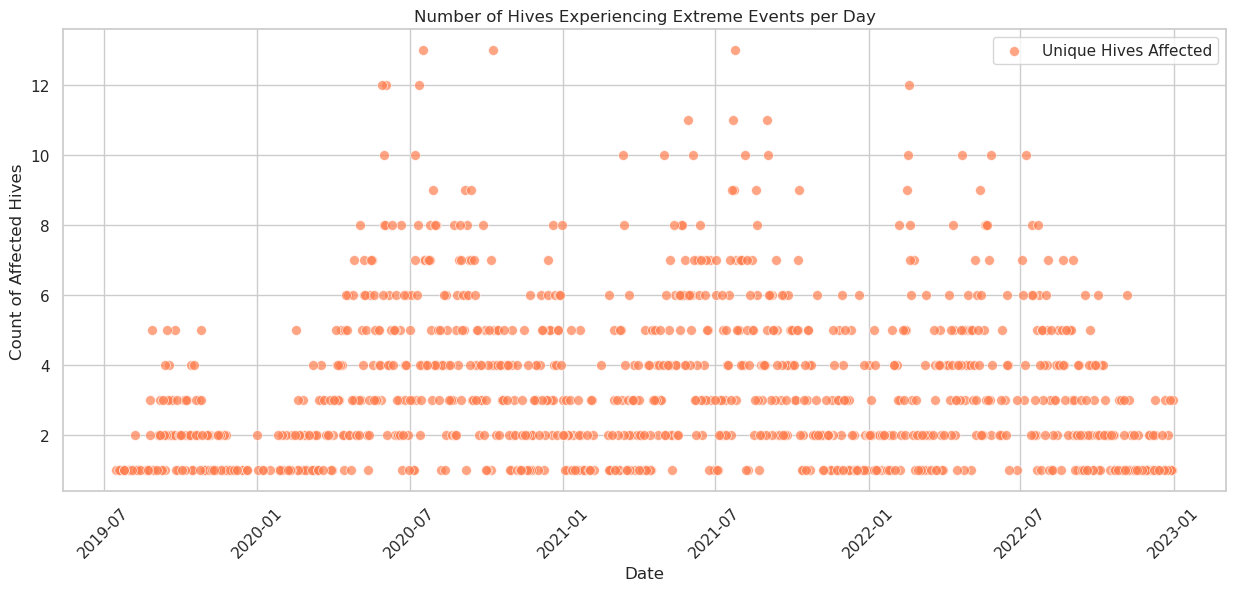

**Number of distinct hives experiencing an extreme event on each day.**

Correlation between *number of extreme events per day* and *number of hives affected that day* = **0.213** — weak. On heavy days the events concentrate in a few hives rather than sweeping the whole apiary.

In [58]:
# --- Date clustering of extreme events ---------------------------------------
show_archived("extreme_events_timeline.png",
    caption="**Count of extreme events per day over the study period.**")
show_archived("extreme_affected_hives.png",
    caption="**Number of distinct hives experiencing an extreme event on each day.**")
corr = PUBLISHED["extreme_invest"]["date_cluster_corr"]
display(Markdown(
    f"Correlation between *number of extreme events per day* and *number of hives "
    f"affected that day* = **{corr:.3f}** — weak. On heavy days the events concentrate in "
    f"a few hives rather than sweeping the whole apiary."))

**Finding 2: extremes are hive-local, not apiary-wide.** The weak date-clustering
correlation (0.213) means extreme days generally hit **individual hives**, not many hives
at once. That argues *against* a dominant external/weather driver and *for* hive-specific
causes (equipment handling, unlogged interventions, sensor artifacts, localized colony
events).

**Consequence for modeling.** Extreme events are (a) rare, (b) unexplained by the
features currently available, and (c) not synchronized across hives. They should be
**modeled separately** from routine behavior, not blended into a single regression that
they distort. This directly shapes the modeling and evaluation choices below.


## 5. Preliminary Modeling

### 5.1 Evaluation protocol

All models use an **80/20 chronological split** on `measurement_date`: the earliest 80%
of observations train the model and the latest 20% test it. This mimics real forecasting
and prevents future information from leaking into training.


In [59]:
# --- Chronological split summary ---------------------------------------------
sp = PUBLISHED["split"]
if LIVE:
    d = model_df.dropna(subset=HISTORY_FEATURES + [TARGET]).sort_values("measurement_date")
    k = int(len(d) * 0.80)
    tr, te = d.iloc[:k], d.iloc[k:]
    split_info = pd.DataFrame({
        "Split": ["Train", "Test"],
        "Observations": [len(tr), len(te)],
        "From": [str(pd.to_datetime(tr['measurement_date']).min().date()),
                 str(pd.to_datetime(te['measurement_date']).min().date())],
        "To": [str(pd.to_datetime(tr['measurement_date']).max().date()),
               str(pd.to_datetime(te['measurement_date']).max().date())],
    })
else:
    split_info = pd.DataFrame({
        "Split": ["Train", "Test"],
        "Observations": [sp["train"], sp["test"]],
        "From": [sp["train_start"], sp["test_start"]],
        "To": [sp["train_end"], sp["test_end"]],
    })
split_info

,Split,Observations,From,To
0,Train,20972,2019-06-25,2022-04-25
1,Test,5243,2022-04-25,2022-12-30


### 5.2 Model results

Three history-only models were trained on the feature set
`previous_day_weight_kg, previous_day_weight_change_kg, rolling_3_day_weight_kg,
rolling_7_day_weight_kg, day_of_year`:

1. **Baseline Random Forest** on *all* observations (routine + extreme).
2. **Routine-only Random Forest**: extreme rows excluded from train and test.
3. **Routine-only Gradient Boosting**: same routine data, sequential boosting.


In [60]:
# --- Model leaderboard -------------------------------------------------------
leaderboard = pd.DataFrame(PUBLISHED["models"]).rename(columns={"R2": "R²"})
if LIVE:
    # Live recomputation of the three models on the history-only feature set.
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

    def chrono_split(frame):
        frame = frame.sort_values("measurement_date")
        k = int(len(frame) * 0.80)
        return frame.iloc[:k], frame.iloc[k:]

    base = model_df.dropna(subset=HISTORY_FEATURES + [TARGET]).copy()
    rows = []

    tr, te = chrono_split(base)
    m = RandomForestRegressor(n_estimators=200, random_state=42).fit(tr[HISTORY_FEATURES], tr[TARGET])
    p = m.predict(te[HISTORY_FEATURES])
    rows.append(("Baseline Random Forest (all events)",
                 mean_absolute_error(te[TARGET], p), root_mean_squared_error(te[TARGET], p),
                 r2_score(te[TARGET], p)))

    routine = base[base["extreme_weight_change_flag"] == False].copy()
    tr, te = chrono_split(routine)
    for name, mdl in [("Routine-only Random Forest",
                       RandomForestRegressor(n_estimators=200, random_state=42)),
                      ("Routine-only Gradient Boosting",
                       GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                 max_depth=3, random_state=42))]:
        mdl.fit(tr[HISTORY_FEATURES], tr[TARGET]); p = mdl.predict(te[HISTORY_FEATURES])
        rows.append((name, mean_absolute_error(te[TARGET], p),
                     root_mean_squared_error(te[TARGET], p), r2_score(te[TARGET], p)))
    leaderboard = pd.DataFrame(rows, columns=["Model", "MAE", "RMSE", "R²"]).round(3)

display(leaderboard)

,Model,MAE,RMSE,R²
0,Baseline Random Forest (all events),0.768,2.437,-0.296
1,Routine-only Random Forest,0.356,0.725,0.198
2,Routine-only Gradient Boosting,0.331,0.717,0.216


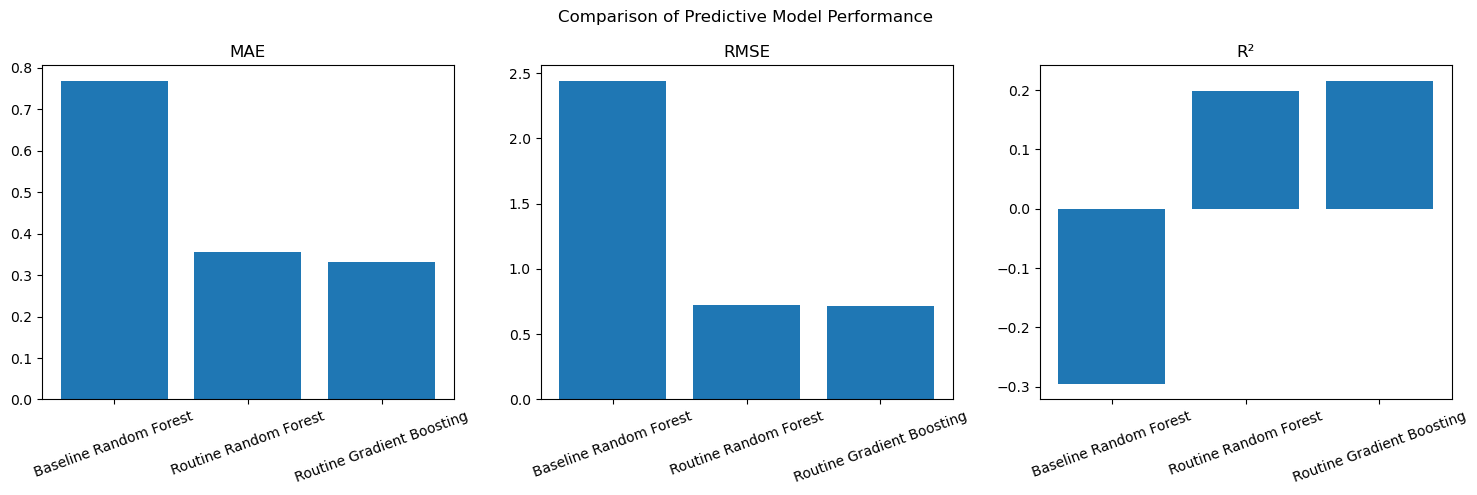

In [61]:
# --- Leaderboard bar chart ---------------------------------------------------
if LIVE:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
        ax.bar(leaderboard["Model"], leaderboard[metric])
        ax.set_title(metric); ax.tick_params(axis="x", rotation=20)
    plt.suptitle("Comparison of Predictive Model Performance")
    plt.tight_layout(); plt.show()
else:
    show_archived("model_comparison_bars.png", width=880)

**Interpretation.** The story is unambiguous:

- The **baseline model that includes extreme events is worse than predicting the mean**
  (R² = −0.30, RMSE = 2.44 kg).
- **Excluding the extreme tail** more than halves MAE (0.77 → 0.36 kg) and cuts RMSE by
  ~70% (2.44 → 0.73 kg), turning R² positive (−0.30 → +0.20). **The biggest lever was
  data framing, not the algorithm.**
- **Gradient Boosting** outperforms Random Forest on the routine data (MAE 0.331, RMSE
  0.717, R² 0.216): a real but modest gain, signalling that further improvement needs
  *richer features*.


### 5.3 Routine-model diagnostics


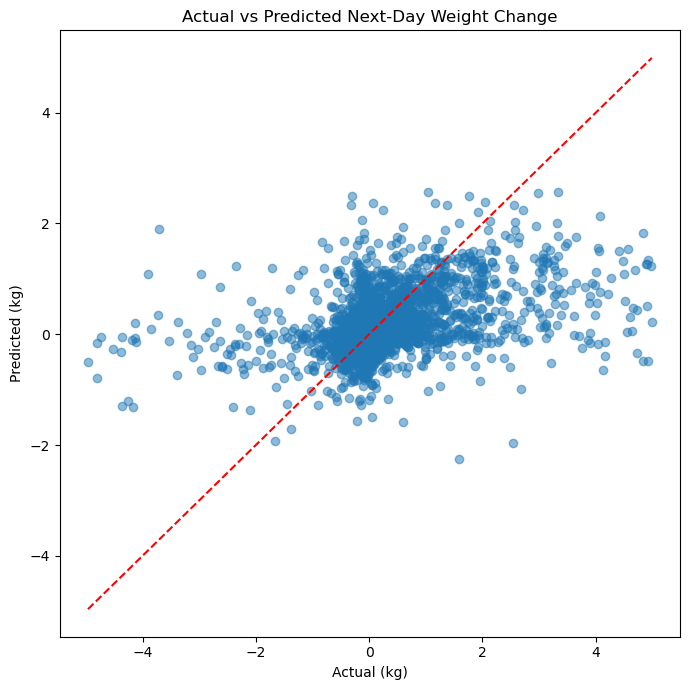

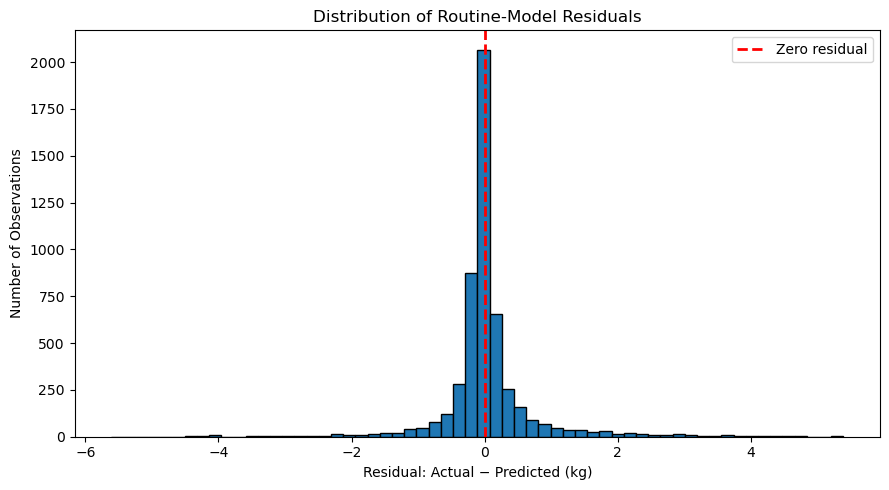

In [62]:
# --- Actual vs predicted and residual diagnostics (routine model) ------------
if LIVE:
    from sklearn.ensemble import RandomForestRegressor
    routine = model_df[model_df["extreme_weight_change_flag"] == False].dropna(
        subset=HISTORY_FEATURES + [TARGET]).sort_values("measurement_date")
    k = int(len(routine) * 0.80); tr, te = routine.iloc[:k], routine.iloc[k:]
    rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(
        tr[HISTORY_FEATURES], tr[TARGET])
    pred = rf.predict(te[HISTORY_FEATURES]); resid = te[TARGET].values - pred

    plt.figure(figsize=(7, 7))
    plt.scatter(te[TARGET], pred, alpha=0.5)
    lo, hi = te[TARGET].min(), te[TARGET].max()
    plt.plot([lo, hi], [lo, hi], "r--")
    plt.title("Actual vs Predicted Next-Day Weight Change")
    plt.xlabel("Actual (kg)"); plt.ylabel("Predicted (kg)")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(9, 5))
    plt.hist(resid, bins=60, edgecolor="black")
    plt.axvline(0, color="red", linestyle="--", linewidth=2)
    plt.title("Distribution of Routine-Model Residuals")
    plt.xlabel("Residual: Actual - Predicted (kg)"); plt.ylabel("Observations")
    plt.tight_layout(); plt.show()
else:
    show_archived("actual_vs_predicted_routine.png", width=560)
    show_archived("residual_distribution_routine.png", width=720)

**Diagnostics.** On routine data, predictions track the 1:1 line for small changes
and compress toward the mean for larger gains/losses (the model under-reacts at the
edges). Residuals are centered near zero with no strong bias, but retain longer-than-normal
tails. The residual structure that additional environmental/management features are meant
to absorb.


## 6. Milestone 3: Answers to the Five Questions

**1. Will I be able to answer the questions I want to answer with the data I have?**
**Partly; yes for routine behavior, not yet for extremes.** The 78-hive, 26,215-row daily
dataset is sufficient to predict *routine* next-day weight change (routine R² ≈ 0.20 with
history features alone, and the strongest signals like recent weight and seasonality are
fully populated). It is **not** sufficient, on its own, to predict the 1.7% extreme events:
they are unexplained by the current features and by the logged beekeeper observations.
Closing that gap requires additional data (NOAA weather; better-aligned management logs).
The environmental sensor channels are usable but **23–35% missing**, which constrains how
heavily we can rely on them.

**2. What visualizations are especially useful for explaining my data?** The
**target-distribution histogram** (full + routine zoom) is the single clearest explainer, as
it shows the routine core and extreme tails at a glance and justifies the whole modeling
strategy. The **multi-panel hive weight time series** is best for non-technical audiences.
The **feature-importance bar chart** communicates what drives predictions, and the
**extreme-event timeline / affected-hives plots** carry the "hive-local, not apiary-wide"
finding. (Sections 3–5.)

**3. Do I need to adjust the data and/or the driving questions?** **Yes.** Split the
driving question into two: *(a)* predict **routine** next-day weight change (regression,
current approach), and *(b)* **explain/flag extreme** weight-change events (a separate
anomaly-detection/classification track). Keep the extreme rows in the dataset but
**flagged and modeled separately** rather than silently dropped, and add explanatory data
(weather, management) before judging whether extremes are predictable.

**4. Do I need to adjust my model/evaluation choices?** **Yes, mainly evaluation.** A
single metric over all data is misleading because extremes inflate the error. Adopt a
**segmented evaluation** reporting MAE/RMSE/R² *overall*, on *routine*, and on *extreme*
observations. Keep the **chronological split** (correct for time series). On algorithms,
Random Forest is a fine baseline; **Gradient Boosting already wins modestly** and
LightGBM/XGBoost are worth a proper comparison, but expect the next real gains from
**features, not learners**.

**5. Are my original expectations still reasonable?** **Yes, with sharper scope.**
*Can we predict daily weight change?* Yes for routine days; extremes are an open
question. *Is the German citizen-science dataset enough?* Enough to start; NOAA weather
should add value. *Are tree-based models appropriate?* Yes; RF/GB are reasonable and
boosting looks slightly better. *Is the feature set adequate?* Lag/rolling features work
well; environmental and beekeeper features are the logical next additions.


## 7. Adjusted Plan for Subsequent Milestones

**Driving question.** Keep the primary question (*predict next-day hive weight change*)
but formally split it:
- **Q-A (routine):** regression on `|change| ≤ 5 kg`, which is the main predictive track.
- **Q-B (extreme):** separately **explain and flag** `|change| > 5 kg` events, treated as
  anomaly detection / classification rather than forced into the regressor.

**Data adjustments.**
- Retain extreme rows, flagged; never drop them.
- Integrate **NOAA GHCN-Daily** (TMAX/TMIN/PRCP) joined to each hive's lat/lon and date.
- Re-examine the **beekeeper observation logs** for timestamp alignment. The current
  logs show ~0 correspondence with extremes, which may be a *join/alignment* problem as
  much as a true absence of signal, and is worth confirming before discarding them.
- Plan for **sensor missingness** (23–35%): imputation or missingness-tolerant models,
  and don't let sensor features shrink the training set.

**Model choices.** Maintain Random Forest as baseline; promote **Gradient Boosting** and
add a like-for-like **LightGBM / XGBoost** comparison on the *real* `honey_model` table
(not simulated data). Prototype a dedicated **extreme-event classifier** for Q-B.

**Evaluation strategy.** Replace single-number scoring with a reusable **segmented
evaluator** (overall / routine / extreme) over the fixed chronological split, so gains
from features vs. algorithms are always separable.

**Data sources.** Confirm NOAA GHCN station coverage over the German bounding box
(lat 47.7–53.8, lon 6.7–13.4); fall back to Open-Meteo (via API → Parquet) only if GHCN
station density is inadequate.


## 8. Next Steps

### 8.1 NOAA weather integration
The GHCN-Daily templates are verified (`the-beehive/weather_duckdb_queries.sql`,
`David_Work/weather-data-query.ipynb`) and read Parquet directly from the public
`s3://noaa-ghcn-pds` bucket. The implementation plan:

1. **Find stations** inside the German hive bounding box by parsing `ghcnd-stations.txt`
   and filtering lat 47.7–53.8, lon 6.7–13.4 (adapt the NYC bounding-box query below).
2. **Pull TMAX, TMIN, PRCP** for 2019–2022 from the year/element-partitioned Parquet
   (values are tenths of a unit, so divide by 10).
3. **Assign each hive its nearest station** and join weather to `honey_model` on
   (nearest-station, date).
4. **Engineer weather features:** same-day and lagged temperature/precipitation, and
   short rolling windows, mirroring the existing weight features.


### 8.2 Expanded feature engineering
- **Weather features** from 8.1 (temp/precip, lags, rolling windows): the highest-value
  additions given the current feature-importance ceiling.
- **Cyclical seasonal encoding**: `sin_day`/`cos_day` (from Joshua's harness) so day-of-year
  wraps continuously across the New Year instead of jumping 365 → 1.
- **Beekeeper observation features**: once timestamp alignment is confirmed (Section 7),
  encode recency/counts of treatment, feeding, honey, swarming, and death events.
- **Hive-level context**: per-hive baselines/identity effects, motivated by the finding
  that extremes are hive-local.
- **Missingness handling**: impute or use missingness-tolerant learners so the 23–35%
  sensor gaps don't quietly shrink the usable data.

### 8.3 Model iteration
- **Segmented evaluator** (overall / routine / extreme) as reusable functions over the
  fixed chronological split.
- **Algorithm comparison on real data**: Random Forest vs. Gradient Boosting vs.
  LightGBM/XGBoost, re-running Joshua's benchmarking harness against `honey_model`
  (replacing the simulated `clean_hive_features.csv`).
- **Dedicated extreme-event track**: a classifier/anomaly detector for `|change| > 5 kg`,
  reported separately from the routine regressor.
- **Iterate features → re-evaluate**, expecting the weather and management channels to be
  where routine R² moves beyond ~0.2.

---

## Summary
The pipeline, EDA, extreme-event investigation, and baseline models establish a
reproducible foundation. The central finding, that **routine hive behavior is predictable
(R² ≈ 0.2 from history alone) while the rare 1.7% extreme tail is not yet explainable and
is hive-local**, sets a clear agenda: bring in NOAA weather, align the beekeeper logs,
handle sensor missingness, and evaluate routine and extreme regimes separately.
